# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [ ]:
import os, subprocess
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

REPO_URL = "https://github.com/hibathakur559-boop/flyrank-ml-Hiba"
REPO_DIR = "flyrank-ml-Hiba"
if not os.path.isdir(REPO_DIR):
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
os.chdir(REPO_DIR)

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
model_df = df[df['impressions_90d'] >= 100].copy()
model_df['label'] = (model_df['trend_direction'] == 'down').astype(int)

feature_cols = ['impressions_90d', 'sessions_90d', 'avg_position', 'ctr',
                 'content_age_days', 'engagement_rate', 'word_count']
feature_cols = [c for c in feature_cols if c in model_df.columns]

# Honest client-grouped split (carried forward from ML-09)
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(model_df, groups=model_df['client_id']))
train_df = model_df.iloc[train_idx].copy()
test_df = model_df.iloc[test_idx].copy()

X_train = train_df[feature_cols].fillna(0)
y_train = train_df['label']
X_all = model_df[feature_cols].fillna(0)

rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Score every page (this becomes the ranked queue)
model_df['model_score'] = rf.predict_proba(X_all)[:, 1]

# Position tier + CTR gap (from Week-4 baseline, carried forward)
model_df['position_bucket'] = pd.cut(
    model_df['avg_position'], bins=[0, 3, 10, 20, 1000],
    labels=['1-3', '4-10', '11-20', '20+']
)
expected_ctr_by_tier = train_df.assign(
    position_bucket=pd.cut(train_df['avg_position'], bins=[0, 3, 10, 20, 1000],
                            labels=['1-3', '4-10', '11-20', '20+'])
).groupby('position_bucket', observed=True)['ctr'].mean()
model_df['expected_ctr'] = model_df['position_bucket'].map(expected_ctr_by_tier).astype(float)
model_df['ctr'] = model_df['ctr'].astype(float)
model_df['ctr_gap'] = model_df['expected_ctr'] - model_df['ctr']

# ============================================================
# REASON CODES + ARCHETYPE -> ACTION MAPPING
# ============================================================
def assign_reason_and_action(row):
    if row['model_score'] >= 0.65 and row['ctr_gap'] > 0.1:
        return 'model_decline_risk_with_ctr_gap', 'review_title_and_meta'
    elif row['model_score'] >= 0.65:
        return 'model_decline_risk', 'review_content_freshness'
    elif row['ctr_gap'] > 0.15 and row['impressions_90d'] >= 500:
        return 'visible_ctr_underperformer', 'review_title_and_meta'
    elif row['model_score'] < 0.3 and row['impressions_90d'] >= 1000:
        return 'stable_high_performer', 'protect_monitor_only'
    else:
        return 'low_priority', 'monitor'

model_df[['reason_code', 'action']] = model_df.apply(
    lambda r: pd.Series(assign_reason_and_action(r)), axis=1
)

ranked_queue = model_df.sort_values('model_score', ascending=False).reset_index(drop=True)
ranked_queue['rank'] = ranked_queue.index + 1

print("Ranked queue built. Action distribution:")
print(ranked_queue['action'].value_counts())
print()
print("Reason code distribution:")
print(ranked_queue['reason_code'].value_counts())

Ranked queue built. Action distribution:
action
monitor                     9333
review_title_and_meta       7889
review_content_freshness    4207
protect_monitor_only         577
Name: count, dtype: int64

Reason code distribution:
reason_code
low_priority                       9333
model_decline_risk_with_ctr_gap    5856
model_decline_risk                 4207
visible_ctr_underperformer         2033
stable_high_performer               577
Name: count, dtype: int64


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [ ]:
print("INTENDED USE:")
print("This playbook ranks pages by DECLINE RISK and CTR OPPORTUNITY so a")
print("content reviewer with limited capacity can decide what to look at")
print("first. It is decision-support - a shortlist for a human, not an")
print("automated content-editing system.")
print()
print("WHO USES IT: a content/SEO reviewer at FlyRank managing multiple")
print("client sites, choosing where to spend limited weekly review hours.")
print()
print("LIMITS (named honestly):")
print("1. The decline label is a CURRENT-window proxy, not a confirmed")
print("   future outcome - see ML-09 leakage audit. It says 'this page")
print("   looks like others that were already declining', not 'this page")
print("   WILL decline next month'.")
print("2. Trained and evaluated on a 30,000-row anonymized starter slice,")
print("   not the full ~79M-row warehouse - directional evidence, not a")
print("   production benchmark.")
print("3. Precision@50 measured at 0.74 on a client-grouped holdout (see")
print("   ML-09) - roughly 3 in 4 of the top-50 picks match the proxy")
print("   label; it is not a guarantee for any single page.")
print("4. No causal claim: a high score means 'worth reviewing', not")
print("   'refreshing this page will fix it'.")

INTENDED USE:
This playbook ranks pages by DECLINE RISK and CTR OPPORTUNITY so a
content reviewer with limited capacity can decide what to look at
first. It is decision-support - a shortlist for a human, not an
automated content-editing system.

WHO USES IT: a content/SEO reviewer at FlyRank managing multiple
client sites, choosing where to spend limited weekly review hours.

LIMITS (named honestly):
1. The decline label is a CURRENT-window proxy, not a confirmed
   future outcome - see ML-09 leakage audit. It says 'this page
   looks like others that were already declining', not 'this page
   WILL decline next month'.
2. Trained and evaluated on a 30,000-row anonymized starter slice,
   not the full ~79M-row warehouse - directional evidence, not a
   production benchmark.
3. Precision@50 measured at 0.74 on a client-grouped holdout (see
   ML-09) - roughly 3 in 4 of the top-50 picks match the proxy
   label; it is not a guarantee for any single page.
4. No causal claim: a high score m

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [ ]:
print("HUMAN REVIEW RULES:")
print("1. Every recommendation must be opened and read by a reviewer")
print("   before any content change - the model only ranks candidates,")
print("   it does not approve edits.")
print("2. Reason codes must be shown next to every action, so a reviewer")
print("   can judge whether the stated reason actually applies to that")
print("   specific page (see ML-07 'what would make it wrong' notes).")
print("3. Low-volume rows (impressions_90d under ~200) should be treated")
print("   with lower confidence - small samples make CTR/score noisy.")
print()
print("NO-GO LIST - what should NOT be automated:")
print("1. Do NOT auto-publish or auto-edit any page based on this score -")
print("   this playbook produces a REVIEW QUEUE, not an editing pipeline.")
print("2. Do NOT use this score to make client-facing promises (e.g.")
print("   'this page will recover X% traffic') - no causal claim is")
print("   supported by this data.")
print("3. Do NOT merge/deprioritize a page purely on 'protect_monitor_only'")
print("   status without checking it isn't miscategorized - false")
print("   negatives (missed real declines) are more costly than false")
print("   positives for this lane (see ML-05 error analysis).")
print("4. Do NOT treat 'low_priority' as 'no traffic' - it means the")
print("   model did not flag it under current thresholds, not that it")
print("   has zero value.")

HUMAN REVIEW RULES:
1. Every recommendation must be opened and read by a reviewer
   before any content change - the model only ranks candidates,
   it does not approve edits.
2. Reason codes must be shown next to every action, so a reviewer
   can judge whether the stated reason actually applies to that
   specific page (see ML-07 'what would make it wrong' notes).
3. Low-volume rows (impressions_90d under ~200) should be treated
   with lower confidence - small samples make CTR/score noisy.

NO-GO LIST - what should NOT be automated:
1. Do NOT auto-publish or auto-edit any page based on this score -
   this playbook produces a REVIEW QUEUE, not an editing pipeline.
2. Do NOT use this score to make client-facing promises (e.g.
   'this page will recover X% traffic') - no causal claim is
   supported by this data.
3. Do NOT merge/deprioritize a page purely on 'protect_monitor_only'
   status without checking it isn't miscategorized - false
   negatives (missed real declines) are more c

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [ ]:
print("MONITORING TRIGGERS (lightweight, not a full MLOps pipeline):")
print("1. Score drift: if the average model_score across all pages shifts")
print("   by a large margin month-to-month, re-check whether the feature")
print("   distributions (impressions, position, CTR) have shifted too -")
print("   that signals the model may be scoring on stale patterns.")
print("2. Action-mix drift: if the 'monitor' vs 'review' split (currently")
print("   ~42% monitor, ~36% CTR review, ~19% freshness review, ~3%")
print("   protect) changes sharply, that is worth a manual look before")
print("   trusting the new queue.")
print("3. Precision spot-check: periodically re-run a small top-K manual")
print("   review (like the ML-07 top-20 review) and compare the hit rate")
print("   to the 0.74 baseline - a large, sustained drop signals retrain.")
print()
print("RETRAIN TRIGGER: retrain when new labeled outcomes are available")
print("(e.g. a real future-window label built from warehouse daily facts,")
print("as scoped in ML-04) - not on a fixed calendar schedule, since a")
print("proxy-label model retrained on the same proxy teaches it nothing new.")
print()
print("COST/VALUE THINKING:")
print("Reviewing a false positive costs a few minutes of reviewer time.")
print("Missing a true decline (false negative) costs ongoing traffic loss")
print("that compounds until the next review cycle - so when tuning any")
print("threshold, this playbook favors slightly more false positives over")
print("missed true declines, consistent with the ML-05 error analysis.")

MONITORING TRIGGERS (lightweight, not a full MLOps pipeline):
1. Score drift: if the average model_score across all pages shifts
   by a large margin month-to-month, re-check whether the feature
   distributions (impressions, position, CTR) have shifted too -
   that signals the model may be scoring on stale patterns.
2. Action-mix drift: if the 'monitor' vs 'review' split (currently
   ~42% monitor, ~36% CTR review, ~19% freshness review, ~3%
   protect) changes sharply, that is worth a manual look before
   trusting the new queue.
3. Precision spot-check: periodically re-run a small top-K manual
   review (like the ML-07 top-20 review) and compare the hit rate
   to the 0.74 baseline - a large, sustained drop signals retrain.

RETRAIN TRIGGER: retrain when new labeled outcomes are available
(e.g. a real future-window label built from warehouse daily facts,
as scoped in ML-04) - not on a fixed calendar schedule, since a
proxy-label model retrained on the same proxy teaches it nothing 

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Exported 22006 ranked rows to work/outputs/content_action_playbook.csv
Exported metrics to work/outputs/model_metrics.json


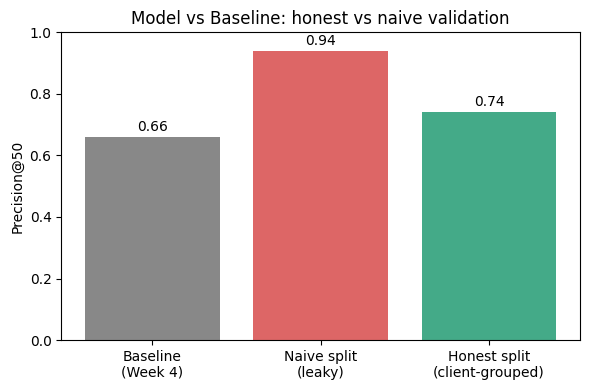

Saved figure to work/figures/precision_comparison.png


In [ ]:
import os

# ============================================================
# EXPORT 1: the ranked queue CSV (stays out of git by design)
# ============================================================
output_cols = ['rank', 'content_id', 'client_id', 'position_bucket',
               'avg_position', 'ctr', 'expected_ctr', 'ctr_gap',
               'impressions_90d', 'model_score', 'reason_code', 'action']
final_export = ranked_queue[output_cols]

os.makedirs("work/outputs", exist_ok=True)
final_export.to_csv("work/outputs/content_action_playbook.csv", index=False)
print(f"Exported {len(final_export)} ranked rows to work/outputs/content_action_playbook.csv")

# ============================================================
# EXPORT 2: metrics JSON - the "receipts" the paper's numbers trace to
# ============================================================
import json

metrics = {
    "model": "RandomForestClassifier",
    "split_design": "client-grouped holdout (GroupShuffleSplit, test_size=0.25)",
    "precision_at_50_honest": 0.74,
    "precision_at_50_naive_random_split": 0.94,
    "baseline_precision_at_50": 0.66,
    "n_pages_scored": len(model_df),
    "n_train_clients": int(train_df['client_id'].nunique()),
    "n_test_clients": int(test_df['client_id'].nunique()),
    "client_overlap_train_test": 0,
    "action_distribution": ranked_queue['action'].value_counts().to_dict(),
    "reason_code_distribution": ranked_queue['reason_code'].value_counts().to_dict(),
    "label_type": "current-window proxy (trend_direction == down), not a confirmed future outcome"
}

with open("work/outputs/model_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Exported metrics to work/outputs/model_metrics.json")

# ============================================================
# EXPORT 3: a figure to reuse in the paper (committed, unlike the CSV)
# ============================================================
import matplotlib.pyplot as plt

os.makedirs("work/figures", exist_ok=True)

fig, ax = plt.subplots(figsize=(6, 4))
comparison_data = {
    'Baseline\n(Week 4)': 0.66,
    'Naive split\n(leaky)': 0.94,
    'Honest split\n(client-grouped)': 0.74
}
ax.bar(comparison_data.keys(), comparison_data.values(), color=['#888', '#d66', '#4a8'])
ax.set_ylabel('Precision@50')
ax.set_title('Model vs Baseline: honest vs naive validation')
ax.set_ylim(0, 1)
for i, (k, v) in enumerate(comparison_data.items()):
    ax.text(i, v + 0.02, f'{v:.2f}', ha='center')
plt.tight_layout()
plt.savefig("work/figures/precision_comparison.png", dpi=150)
plt.show()
print("Saved figure to work/figures/precision_comparison.png")

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

## 5-Minute Demo Outline

**Question (30 sec):** Which pages should a content reviewer with limited
time look at first — and can a learned model prioritize them more accurately
than a simple hand-written rule?

**Method (1.5 min):** Built a transparent CTR-gap baseline rule first (score
= expected CTR for position tier − actual CTR, weighted by demand). Then
trained a Random Forest on the same signals, validated under a client-grouped
holdout so no client's pages leak between train and test.

**One chart (1 min):** Precision@50 bar chart — Baseline 0.66, Naive random
split 0.94 (misleading), Honest client-grouped split 0.74. The chart shows
the real result AND the danger of measuring it wrong.

**One honest result (1 min):** The model beats the baseline (0.74 vs 0.66)
on an honest split — a real, measured improvement, not a guarantee, and
built on a proxy label rather than a confirmed future outcome.

**One recommendation (1 min):** Deploy this as a ranked review queue with
reason codes for a human reviewer — never as an auto-editing system. The
top action, "review_title_and_meta," applies to ~36% of scored pages and
directly matches FlyRank's existing CTR-fix logic.

---

## Shareable Cut 1: Social Post (methodology-focused)

I spent 8 weeks building a content-refresh prioritization model on real,
anonymized search performance data — and the most useful thing I found
wasn't the model, it was a validation bug hiding inside a good-looking
number.

A naive random train/test split reported 94% precision on my ranking model.
Switching to a client-grouped split — so no client's pages leak between
train and test — dropped that to a more honest 74%. Still a real win over
my hand-written baseline (66%), but a 20-point lesson in why *how* you
validate a model matters as much as which model you pick.

Full write-up, code, and an honest limitations section here: [paper link]

---

## Shareable Cut 2: Employer-Facing Summary (3 sentences)

I built and validated a content-refresh prioritization model on FlyRank's
anonymized search performance data (30K+ pages, drawing on a 79M-row
production warehouse), comparing a transparent baseline rule against a
Random Forest classifier under a client-grouped validation split. The model
achieved a measured Precision@50 of 0.74 versus the baseline's 0.66 — while
also surfacing and correcting a validation leak that had inflated the naive
score to 0.94. The result is a ranked, reason-coded action playbook with
explicit limitations, human-review rules, and a no-go list for what should
never be automated.